License

- Content (explanatory text, figures): CC BY 4.0 — see /LICENSE-CONTENT
- Code cells and standalone code files: MIT License — see /LICENSE-CODE

Attribution example: Getman, R. (2026). CBE 3610 Python Notebooks and Course Materials. https://github.com/dr-rachel-bg-teaching/CBE3610


=== SIMULATION METRICS ===
Final Selectivity (S_DE): 2.7436
Conversion (X): 0.3180
Maximum Temperature: 492.25 K


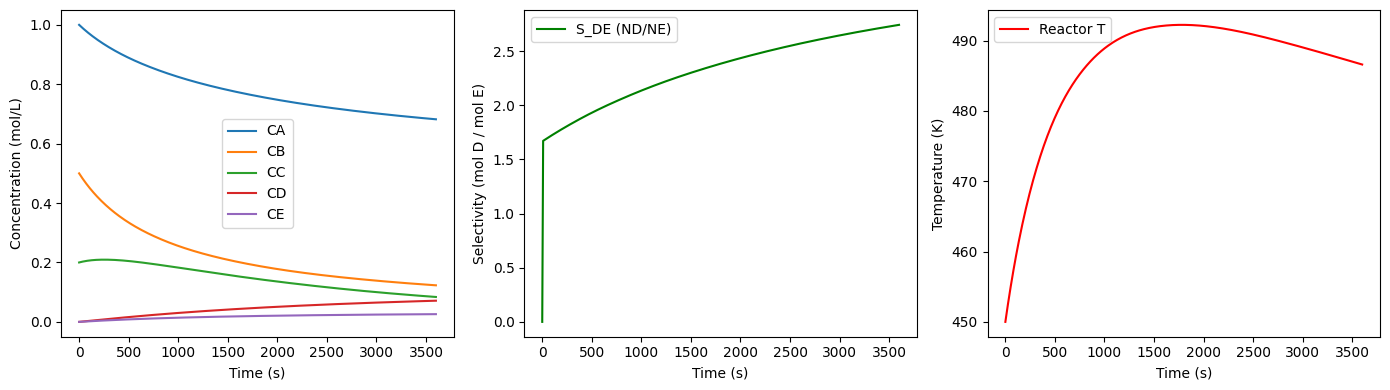

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Reactor information and parameters
V = 2000          # Reactor Volume (L)
Ta0 = 400         # Coolant inlet temperature (K)
UA = 0            # Heat exchanger coefficient (kcal/s*K) [0 for adiabatic, 0.1 for active]
t_final = 3600    # Total batch run time (s)
R = 0.001986      # Gas constant (kcal/mol*K)

# Initial Concentrations & Temperature
CA0, CB0, CC0, CD0, CE0 = 1.0, 0.5, 0.2, 0.0, 0.0
T0 = 450          # Initial Temperature (K)

# Thermodynamic data
CP = np.array([0.01, 0.01, 0.05, 0.08, 0.05])  # CPA, CPB, CPC, CPD, CPE
H1B, H2C, H3B = -5, 10, -50
Hrxn = np.array([H1B * 2, H2C * (3 / 2), H3B * (1 / 3)])  # H1A, H2A, H3C

# Kinetic Parameters (k0, T0, E)
k1A0, T1A0, E1 = 1e-3, 450, 0
k2A0, T2A0, E2 = (1e-3) / 3, 450, 0
k3C0, T3C0, E3 = 0.6e-3, 450, 0

# Stoichiometry Matrix
nu = np.array([
    [-1, -2, 1, 0, 0],
    [-1, 0, -3/2, 1/2, 0],
    [0, -1/3, -1, 0, 1/3]
])

# batch reactor design equations
def batch_reactor(t, y):
    N = y[:5]  # NA, NB, NC, ND, NE
    T = y[5]   # Temperature

    # Concentrations (Liquid phase, V is constant)
    CA, CB, CC, _, _ = N / V

    # rate constants (Arrhenius equations)
    k1A = k1A0 * np.exp((E1 / R) * (1 / T1A0 - 1 / T))
    k2A = k2A0 * np.exp((E2 / R) * (1 / T2A0 - 1 / T))
    k3C = k3C0 * np.exp((E3 / R) * (1 / T3C0 - 1 / T))
    r = np.array([k1A * CA * CB**2, k2A * CA * CC, k3C * CB * CC])

    # mole balances
    rnet = np.dot(nu.T, r)
    dNdt = V * rnet

    # energy balance
    Qgb = np.dot(-Hrxn, r) * V
    Qrb = UA * (Ta0 - T)
    dTdt = (Qgb + Qrb) / np.dot(N, CP)

    return [*dNdt, dTdt]

# run the simulation
init_moles = np.array([CA0, CB0, CC0, CD0, CE0]) * V
initial_conditions = [*init_moles, T0]
t_eval = np.linspace(0, t_final, 400)

sol = solve_ivp(batch_reactor, [0, t_final], initial_conditions, t_eval=t_eval)

# extract data
time_steps = sol.t
NA, NB, NC, ND, NE, T = sol.y
C = sol.y[:5] / V  # 2D concentration matrix [CA, CB, CC, CD, CE]

# Calculate Selectivity profile safely over time
with np.errstate(divide='ignore', invalid='ignore'):
    S_DE_time = np.where(NE == 0, 0, ND / NE)

print("=== SIMULATION METRICS ===")
print(f"Final Selectivity (S_DE): {ND[-1] / NE[-1]:.4f}")
print(f"Conversion (X): {(init_moles[0] - NA[-1]) / init_moles[0]:.4f}")
print(f"Maximum Temperature: {max(T):.2f} K")

# --- PLOTTING ---
plt.figure(figsize=(14, 4))

# Plot 1: Concentrations vs Time
plt.subplot(1, 3, 1)
labels = ["CA", "CB", "CC", "CD", "CE"]
for i, label in enumerate(labels):
    plt.plot(time_steps, C[i], label=label)
plt.xlabel("Time (s)")
plt.ylabel("Concentration (mol/L)")
plt.legend()

# Plot 2: Selectivity vs Time
plt.subplot(1, 3, 2)
plt.plot(time_steps, S_DE_time, "g-", label="S_DE (ND/NE)")
plt.xlabel("Time (s)")
plt.ylabel("Selectivity (mol D / mol E)")
plt.legend()

# Plot 3: Temperature vs Time
plt.subplot(1, 3, 3)
plt.plot(time_steps, T, "r-", label="Reactor T")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.legend()

plt.tight_layout()
plt.show()